# FER2013 — Architecture 2: CNN baseline

## 1. Setup

In [ ]:

import os, random, time
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
import wandb

def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

SEED = 42
set_seed(SEED)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print("Using device:", device)

DATA_DIR = "data"
EMOTIONS = ["Angry", "Disgust", "Fear", "Happy", "Sad", "Surprise", "Neutral"]
NUM_CLASSES = len(EMOTIONS)

Using device: mps


## 2. Data loading & splits

In [12]:
df = pd.read_csv(f"{DATA_DIR}/icml_face_data.csv")
df.columns = [c.strip() for c in df.columns]

def pixels_to_array(frame):
    X = np.stack([np.asarray(p.split(), dtype=np.uint8) for p in frame["pixels"]])
    return X.reshape(-1, 48, 48)

train_df = df[df["Usage"] == "Training"].reset_index(drop=True)
val_df   = df[df["Usage"] == "PublicTest"].reset_index(drop=True)
test_df  = df[df["Usage"] == "PrivateTest"].reset_index(drop=True)

X_train = pixels_to_array(train_df); y_train = train_df["emotion"].to_numpy()
X_val   = pixels_to_array(val_df);   y_val   = val_df["emotion"].to_numpy()
X_test  = pixels_to_array(test_df);  y_test  = test_df["emotion"].to_numpy()

MEAN = float(X_train.mean() / 255.0)
STD  = float(X_train.std()  / 255.0)
print(f"train {X_train.shape}  val {X_val.shape}  test {X_test.shape}")
print(f"normalized mean/std (train): {MEAN:.4f} / {STD:.4f}")

counts = np.bincount(y_train, minlength=NUM_CLASSES)
class_weights = counts.sum() / (NUM_CLASSES * counts)
class_weights = torch.tensor(class_weights, dtype=torch.float32)
for i, e in enumerate(EMOTIONS):
    print(f"{e:9s} n={counts[i]:5d}  weight={class_weights[i]:.2f}")

train (28709, 48, 48)  val (3589, 48, 48)  test (3589, 48, 48)
normalized mean/std (train): 0.5077 / 0.2550
Angry     n= 3995  weight=1.03
Disgust   n=  436  weight=9.41
Fear      n= 4097  weight=1.00
Happy     n= 7215  weight=0.57
Sad       n= 4830  weight=0.85
Surprise  n= 3171  weight=1.29
Neutral   n= 4965  weight=0.83


## 3. Dataset & transforms

In [13]:
class FER2013Dataset(Dataset):
    def __init__(self, X, y, augment=False):
        self.X = X
        self.y = torch.tensor(y, dtype=torch.long)
        self.augment = augment
        self.aug = transforms.Compose([
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(10),
            transforms.RandomResizedCrop(48, scale=(0.85, 1.0), antialias=True),
        ])
        self.normalize = transforms.Normalize(mean=[MEAN], std=[STD])

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        img = torch.from_numpy(self.X[idx]).float().div(255.0).unsqueeze(0)
        if self.augment:
            img = self.aug(img)
        return self.normalize(img), self.y[idx]


def make_loaders(batch_size=64, augment=True, num_workers=0,
                 pin_memory=None, persistent_workers=None):
    tr = FER2013Dataset(X_train, y_train, augment=augment)
    va = FER2013Dataset(X_val,   y_val,   augment=False)
    te = FER2013Dataset(X_test,  y_test,  augment=False)
    if pin_memory is None:
        pin_memory = (device.type == "cuda")
    if persistent_workers is None:
        persistent_workers = num_workers > 0
    common = dict(batch_size=batch_size, num_workers=num_workers,
                  pin_memory=pin_memory, persistent_workers=persistent_workers)
    return (DataLoader(tr, shuffle=True,  **common),
            DataLoader(va, shuffle=False, **common),
            DataLoader(te, shuffle=False, **common))

## 4. Wandb login

In [16]:
import getpass

WANDB_PROJECT = "fer2013-emotion"
WANDB_ENTITY  = None


if not os.environ.get("WANDB_API_KEY"):
    os.environ["WANDB_API_KEY"] = getpass.getpass("Paste your W&B API key (from https://wandb.ai/authorize): ").strip()

wandb.login()

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: toberi23 (toberi23-free-university-of-tbilisi-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

## 5. Training engine

In [17]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, n = 0.0, 0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * xb.size(0)
        correct += (out.argmax(1) == yb).sum().item()
        n += xb.size(0)
    return {"loss": total_loss / n, "acc": correct / n}


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, n = 0.0, 0, 0
    preds_all, true_all = [], []
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        out = model(xb)
        total_loss += criterion(out, yb).item() * xb.size(0)
        preds = out.argmax(1)
        correct += (preds == yb).sum().item()
        n += xb.size(0)
        preds_all.append(preds.cpu())
        true_all.append(yb.cpu())
    preds = torch.cat(preds_all).numpy()
    true  = torch.cat(true_all).numpy()
    return {"loss": total_loss / n,
            "acc": correct / n,
            "f1_macro": f1_score(true, preds, average="macro"),
            "preds": preds, "true": true}

## 6. Sanity checks

In [18]:
import math

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def forward_check(build_model):
    model = build_model().to(device)
    dummy = torch.randn(4, 1, 48, 48, device=device)
    out = model(dummy)
    assert out.shape == (4, NUM_CLASSES), f"expected (4, {NUM_CLASSES}), got {tuple(out.shape)}"
    print(f"forward OK -> logits {tuple(out.shape)},  params {count_params(model):,}")


def init_loss_check(build_model, tol=0.3):
    set_seed(SEED)
    model = build_model().to(device).eval()
    loader, _, _ = make_loaders(batch_size=512, augment=False)
    xb, yb = next(iter(loader))
    xb, yb = xb.to(device), yb.to(device)
    with torch.no_grad():
        loss = nn.CrossEntropyLoss()(model(xb), yb).item()
    expected = math.log(NUM_CLASSES)
    flag = "OK" if abs(loss - expected) < tol else "!! OFF"
    print(f"init loss {loss:.3f}  (expect ~{expected:.3f})  {flag}")


def overfit_one_batch(build_model, steps=200, lr=1e-3):
    set_seed(SEED)
    model = build_model().to(device)
    loader, _, _ = make_loaders(batch_size=32, augment=False)
    xb, yb = next(iter(loader))
    xb, yb = xb.to(device), yb.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    losses = []
    for _ in range(steps):
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward(); optimizer.step()
        losses.append(loss.item())
    with torch.no_grad():
        acc = (model(xb).argmax(1) == yb).float().mean().item()
    print(f"overfit one batch: loss {losses[0]:.3f} -> {losses[-1]:.3f},  batch acc {acc:.1%}")
    return losses


def sanity_checks(build_model):
    forward_check(build_model)
    init_loss_check(build_model)
    overfit_one_batch(build_model)

## 7. Shared building blocks, training engine & HP search

In [19]:

def make_activation(name="relu"):
    name = name.lower()
    table = {"relu": nn.ReLU, "leaky_relu": nn.LeakyReLU,
             "gelu": nn.GELU, "tanh": nn.Tanh, "elu": nn.ELU}
    if name not in table:
        raise ValueError(f"unknown activation: {name}")
    return table[name]()


def apply_init(module, scheme="default", activation="relu"):
    if scheme == "default":
        return module
    for m in module.modules():
        if isinstance(m, (nn.Linear, nn.Conv2d)):
            if scheme == "xavier":
                nn.init.xavier_uniform_(m.weight)
            elif scheme == "kaiming":
                nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
            elif scheme == "normal":
                nn.init.normal_(m.weight, mean=0.0, std=0.02)
            else:
                raise ValueError(f"unknown init scheme: {scheme}")
            if m.bias is not None:
                nn.init.zeros_(m.bias)
    return module

In [20]:
def fit(build_model, arch, epochs=20, lr=1e-3, batch_size=64, augment=False,
        weight_decay=0.0, use_class_weights=True, optimizer_name="adam",
        lr_schedule="none",
        study=None, extra_config=None, run_name=None, notes="", tags=None,
        log_to_wandb=True, watch=True, verbose=True):
    set_seed(SEED)
    model = build_model().to(device)
    train_loader, val_loader, test_loader = make_loaders(batch_size=batch_size, augment=augment)

    weight = class_weights.to(device) if use_class_weights else None
    criterion = nn.CrossEntropyLoss(weight=weight)
    if optimizer_name == "adam":
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif optimizer_name == "sgd":
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=weight_decay)
    elif optimizer_name == "rmsprop":
        optimizer = torch.optim.RMSprop(model.parameters(), lr=lr, momentum=0.9, weight_decay=weight_decay)
    else:
        raise ValueError(f"unknown optimizer: {optimizer_name}")

    if lr_schedule == "none":
        scheduler = None
    elif lr_schedule == "step":
        scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=max(1, epochs // 3), gamma=0.1)
    elif lr_schedule == "cosine":
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    elif lr_schedule == "plateau":
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=2)
    else:
        raise ValueError(f"unknown lr_schedule: {lr_schedule}")

    config = dict(arch=arch, epochs=epochs, lr=lr, batch_size=batch_size,
                  augment=augment, weight_decay=weight_decay,
                  use_class_weights=use_class_weights, optimizer=optimizer_name,
                  lr_schedule=lr_schedule, params=count_params(model), seed=SEED)
    if extra_config:
        config.update(extra_config)

    run = None
    if log_to_wandb:
        all_tags = [arch] + (tags or []) + ([f"study:{study}"] if study else [])
        run = wandb.init(
            project=WANDB_PROJECT, entity=WANDB_ENTITY,
            name=run_name or f"{arch}-lr{lr:g}-bs{batch_size}" + ("-aug" if augment else ""),
            group=arch,
            job_type=study or "train", config=config,
            notes=notes, tags=all_tags, reinit=True)
        if watch:
            wandb.watch(model, criterion, log="all", log_freq=100)

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "val_f1": []}
    best_val_acc, best_epoch, best_state = 0.0, 0, None
    for epoch in range(1, epochs + 1):
        tr = train_one_epoch(model, train_loader, criterion, optimizer)
        va = evaluate(model, val_loader, criterion)
        history["train_loss"].append(tr["loss"]); history["train_acc"].append(tr["acc"])
        history["val_loss"].append(va["loss"]);   history["val_acc"].append(va["acc"])
        history["val_f1"].append(va["f1_macro"])

        if log_to_wandb:
            wandb.log({"epoch": epoch,
                       "train/loss": tr["loss"], "train/acc": tr["acc"],
                       "val/loss": va["loss"], "val/acc": va["acc"],
                       "val/f1_macro": va["f1_macro"],
                       "gap/acc": tr["acc"] - va["acc"],
                       "gap/loss": va["loss"] - tr["loss"],
                       "lr": optimizer.param_groups[0]["lr"]})

        if va["acc"] > best_val_acc:
            best_val_acc, best_epoch = va["acc"], epoch
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        if verbose:
            print(f"[{arch}] epoch {epoch:02d}/{epochs}  "
                  f"train_loss {tr['loss']:.3f} acc {tr['acc']:.3f} | "
                  f"val_loss {va['loss']:.3f} acc {va['acc']:.3f} f1 {va['f1_macro']:.3f}")

        if scheduler is not None:
            scheduler.step(va["acc"]) if lr_schedule == "plateau" else scheduler.step()

    if best_state is not None:
        model.load_state_dict(best_state)
    te = evaluate(model, test_loader, criterion)
    history["best_val_acc"], history["best_epoch"] = best_val_acc, best_epoch
    history["test_acc"], history["test_f1"] = te["acc"], te["f1_macro"]
    print(f"[{arch}] best val acc {best_val_acc:.3f} @ epoch {best_epoch}  |  "
          f"TEST acc {te['acc']:.3f}  f1 {te['f1_macro']:.3f}")

    if log_to_wandb:
        run.summary["best_val_acc"] = best_val_acc
        run.summary["best_epoch"]   = best_epoch
        run.summary["test_acc"]     = te["acc"]
        run.summary["test_f1_macro"] = te["f1_macro"]
        run.summary["test_loss"]    = te["loss"]
        wandb.log({"test/confusion_matrix": wandb.plot.confusion_matrix(
            y_true=te["true"], preds=te["preds"], class_names=EMOTIONS)})
        run.finish()
    return model, history


def plot_history(history, title=""):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
    ax1.plot(history["train_loss"], label="train"); ax1.plot(history["val_loss"], label="val")
    ax1.set_title(f"{title} — loss"); ax1.set_xlabel("epoch"); ax1.legend()
    ax2.plot(history["train_acc"], label="train"); ax2.plot(history["val_acc"], label="val")
    ax2.set_title(f"{title} — accuracy"); ax2.set_xlabel("epoch"); ax2.legend()
    plt.tight_layout(); plt.show()

In [21]:
import itertools, inspect

def _split_kwargs(model_cls, cfg):
    model_params = set(inspect.signature(model_cls.__init__).parameters) - {"self"}
    model_kwargs = {k: v for k, v in cfg.items() if k in model_params}
    fit_kwargs   = {k: v for k, v in cfg.items() if k not in model_params}
    return model_kwargs, fit_kwargs


def _run_one(model_cls, arch, study, cfg):
    model_kwargs, fit_kwargs = _split_kwargs(model_cls, cfg)
    tag = "-".join(f"{k}={round(v, 5) if isinstance(v, float) else v}"
                   for k, v in cfg.items() if k not in ("epochs", "augment", "use_class_weights"))
    _, hist = fit(lambda: model_cls(**model_kwargs), arch=arch, study=study,
                  extra_config=cfg, run_name=f"{arch}-{tag}", watch=False,
                  verbose=False, **fit_kwargs)
    return {**cfg,
            "best_val_acc": round(hist["best_val_acc"], 4),
            "test_acc":     round(hist["test_acc"], 4),
            "test_f1":      round(hist["test_f1"], 4)}


def grid_search(model_cls, arch, param_grid, fixed=None, study="grid-search"):
    fixed = fixed or {}
    keys = list(param_grid)
    combos = list(itertools.product(*param_grid.values()))
    print(f"[grid] {len(combos)} combinations")
    rows = []
    for i, vals in enumerate(combos, 1):
        cfg = {**fixed, **dict(zip(keys, vals))}
        print(f"--- grid {i}/{len(combos)}: {dict(zip(keys, vals))} ---")
        rows.append(_run_one(model_cls, arch, study, cfg))
    return pd.DataFrame(rows).sort_values("best_val_acc", ascending=False).reset_index(drop=True)


def random_search(model_cls, arch, space, n_trials, fixed=None, study="random-search", seed=SEED):
    fixed = fixed or {}
    rng = random.Random(seed)
    rows = []
    for i in range(1, n_trials + 1):
        sample = {k: (v(rng) if callable(v) else rng.choice(v)) for k, v in space.items()}
        cfg = {**fixed, **sample}
        print(f"--- random {i}/{n_trials}: {sample} ---")
        rows.append(_run_one(model_cls, arch, study, cfg))
    return pd.DataFrame(rows).sort_values("best_val_acc", ascending=False).reset_index(drop=True)

## 8. Architecture 2 — CNN

In [22]:
class SmallCNN(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, channels=32, activation="relu",
                 norm="none", dropout=0.0, init="default"):
        super().__init__()

        def norm2d(c):
            if norm == "batch": return nn.BatchNorm2d(c)
            if norm == "layer": return nn.GroupNorm(1, c)
            if norm == "none":  return nn.Identity()
            raise ValueError(f"unknown norm: {norm}")

        self.features = nn.Sequential(
            nn.Conv2d(1, channels, kernel_size=3, padding=1),
            norm2d(channels),
            make_activation(activation),
            nn.MaxPool2d(2),
        )
        head = [nn.Flatten()]
        if dropout > 0:
            head.append(nn.Dropout(dropout))
        head.append(nn.Linear(channels * 24 * 24, num_classes))
        self.classifier = nn.Sequential(*head)

        apply_init(self, init, activation)

    def forward(self, x):
        return self.classifier(self.features(x))

In [23]:
sanity_checks(lambda: SmallCNN())

forward OK -> logits (4, 7),  params 129,351
init loss 1.949  (expect ~1.946)  OK
overfit one batch: loss 1.941 -> 0.001,  batch acc 100.0%


[CNN] epoch 01/20  train_loss 1.863 acc 0.329 | val_loss 1.640 acc 0.353 f1 0.329
[CNN] epoch 02/20  train_loss 1.472 acc 0.444 | val_loss 1.565 acc 0.421 f1 0.356
[CNN] epoch 03/20  train_loss 1.325 acc 0.497 | val_loss 1.531 acc 0.452 f1 0.425
[CNN] epoch 04/20  train_loss 1.230 acc 0.524 | val_loss 1.499 acc 0.450 f1 0.409
[CNN] epoch 05/20  train_loss 1.148 acc 0.557 | val_loss 1.551 acc 0.470 f1 0.433
[CNN] epoch 06/20  train_loss 1.071 acc 0.581 | val_loss 1.595 acc 0.473 f1 0.431
[CNN] epoch 07/20  train_loss 1.019 acc 0.599 | val_loss 1.598 acc 0.464 f1 0.424
[CNN] epoch 08/20  train_loss 0.963 acc 0.619 | val_loss 1.766 acc 0.470 f1 0.441
[CNN] epoch 09/20  train_loss 0.904 acc 0.639 | val_loss 1.685 acc 0.469 f1 0.431
[CNN] epoch 10/20  train_loss 0.859 acc 0.660 | val_loss 1.711 acc 0.460 f1 0.438
[CNN] epoch 11/20  train_loss 0.803 acc 0.682 | val_loss 1.791 acc 0.462 f1 0.453
[CNN] epoch 12/20  train_loss 0.769 acc 0.694 | val_loss 1.870 acc 0.441 f1 0.423
[CNN] epoch 13/2

epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
gap/acc,▁▂▂▃▃▃▄▄▅▅▆▆▆▇▇▇▇▇██
gap/loss,▁▂▂▃▃▄▄▅▄▅▅▆▆▆▇▆▇▇██
lr,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/acc,▁▃▃▄▄▅▅▅▆▆▆▆▇▇▇▇████
train/loss,█▆▅▅▄▄▄▃▃▃▂▂▂▂▂▂▁▁▁▁
val/acc,▁▅▇▇██▇██▇▇▆▇▇██▇▇▇▇
val/f1_macro,▁▃▆▅▇▇▆▇▇▇█▆▇▇█▇▇█▇▇
val/loss,▂▂▁▁▁▂▂▃▃▃▃▄▄▄▆▅▅▆██
best_epoch,6
best_val_acc,0.47256


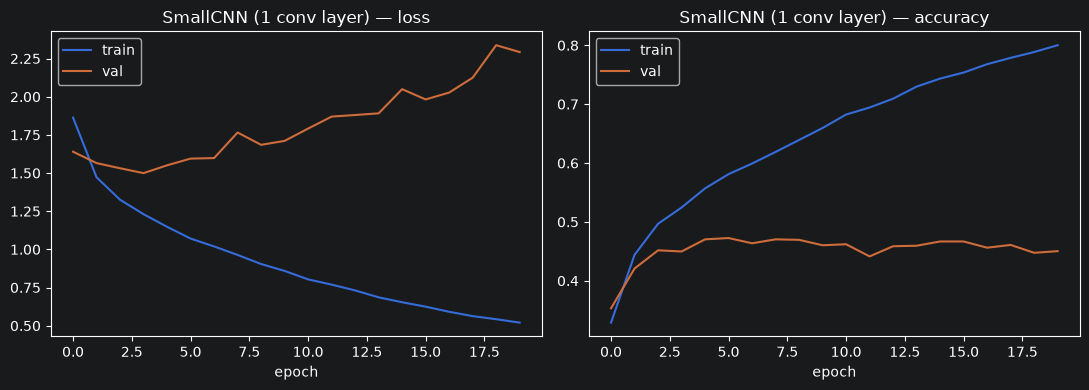


MLP baseline test acc was ~0.424 — CNN test acc: 0.468


In [60]:
cnn_model, cnn_hist = fit(lambda: SmallCNN(), arch="CNN", epochs=20, lr=1e-3, augment=False,
                          notes="One conv block (32 filters) + linear head. First CNN.")

plot_history(cnn_hist, title="SmallCNN (1 conv layer)")
print(f"\nMLP baseline test acc was ~0.424 — CNN test acc: {cnn_hist['test_acc']:.3f}")

### Study 3 — Normalization on the CNN (none vs BatchNorm vs LayerNorm)

In [61]:
norm_df = grid_search(SmallCNN, arch="CNN",
                      param_grid={"norm": ["none", "batch", "layer"]},
                      fixed=dict(epochs=20, lr=1e-3, augment=False),
                      study="norm")
norm_df

[grid] 3 combinations
--- grid 1/3: {'norm': 'none'} ---


[CNN] best val acc 0.473 @ epoch 6  |  TEST acc 0.468  f1 0.423


epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
gap/acc,▁▂▂▃▃▃▄▄▅▅▆▆▆▇▇▇▇▇██
gap/loss,▁▂▂▃▃▄▄▅▄▅▅▆▆▆▇▆▇▇██
lr,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/acc,▁▃▃▄▄▅▅▅▆▆▆▆▇▇▇▇████
train/loss,█▆▅▅▄▄▄▃▃▃▂▂▂▂▂▂▁▁▁▁
val/acc,▁▅▇▇██▇██▇▇▆▇▇██▇▇▇▇
val/f1_macro,▁▃▆▅▇▇▆▇▇▇█▆▇▇█▇▇█▇▇
val/loss,▂▂▁▁▁▂▂▃▃▃▃▄▄▄▆▅▅▆██
best_epoch,6
best_val_acc,0.47256


--- grid 2/3: {'norm': 'batch'} ---


[CNN] best val acc 0.456 @ epoch 15  |  TEST acc 0.462  f1 0.437


epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
gap/acc,▁▃▃▄▄▄▅▅▅▅▆▆▇▇▇▇████
gap/loss,▁▃▃▃▄▄▄▅▅▅▅▆▆▆▆▆▇▇██
lr,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/acc,▁▃▃▄▄▅▅▅▆▆▆▆▇▇▇▇▇███
train/loss,█▅▄▄▃▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁
val/acc,▄▁▅▆▇▇▇█▇▇▇▆▇▇█▇▇▇▇▇
val/f1_macro,▄▁▆▆▇▆▆▇▆▇▇▆▇▇█▇▆▇█▇
val/loss,▃▂▁▁▁▁▂▃▂▂▃▃▄▄▅▄▅▆█▇
best_epoch,15
best_val_acc,0.45584


--- grid 3/3: {'norm': 'layer'} ---


[CNN] best val acc 0.461 @ epoch 5  |  TEST acc 0.452  f1 0.415


epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
gap/acc,▁▃▃▃▄▄▅▅▅▆▆▆▇▇▇▇████
gap/loss,▁▂▃▃▃▄▄▄▅▅▅▅▆▆▆▆▇▇██
lr,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/acc,▁▃▄▄▄▅▅▅▆▆▆▆▇▇▇▇████
train/loss,█▅▅▄▄▃▃▃▃▂▂▂▂▂▂▂▁▁▁▁
val/acc,▁▁▄▆█▇▇█▇▇▇▆▆▆▇▇▆▆▇▇
val/f1_macro,▂▁▅▆▇▇▆▇▇▇█▆▇▇█▇▇▇█▇
val/loss,▂▁▁▁▁▂▂▃▃▃▃▄▄▄▅▅▆▆█▇
best_epoch,5
best_val_acc,0.46141


,epochs,lr,augment,norm,best_val_acc,test_acc,test_f1
0,20,0.001,False,none,0.4726,0.4681,0.4225
1,20,0.001,False,layer,0.4614,0.4519,0.4150
2,20,0.001,False,batch,0.4558,0.4620,0.4371


## 9. Tuning SmallCNN

### Search 1 — Learning rate (log-spaced grid)

In [24]:
lr_df = grid_search(SmallCNN, arch="CNN",
                    param_grid={"lr": [1e-4, 3e-4, 1e-3, 3e-3, 1e-2]},
                    fixed=dict(epochs=20, augment=False),
                    study="tune-lr")
display(lr_df)

BEST_LR = float(lr_df.iloc[0]["lr"])
print(f"\n>>> best LR = {BEST_LR:g}  "
      f"(val {lr_df.iloc[0]['best_val_acc']:.4f}, test {lr_df.iloc[0]['test_acc']:.4f})")


[grid] 5 combinations
--- grid 1/5: {'lr': 0.0001} ---


wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


[CNN] best val acc 0.467 @ epoch 19  |  TEST acc 0.471  f1 0.426


epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
gap/acc,▃▁▄▂▂▃▄▃▄▅▆▅▆▆▆▆▇▇▆█
gap/loss,▁▂▃▃▃▄▅▅▅▅▆▆▆▆▇▇▇▇██
lr,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/acc,▁▃▄▄▅▅▅▆▆▆▇▇▇▇▇▇████
train/loss,█▇▆▅▅▄▄▄▃▃▃▂▂▂▂▂▁▁▁▁
val/acc,▁▅▄▆▆▇▆█▇▇▆▇▇▇▇█▇▇█▇
val/f1_macro,▁▄▃▆▆▆▆▇▇▆▅▇▇▇▇▇▇▇█▇
val/loss,█▅▆▄▄▄▃▃▂▂▂▂▁▁▂▁▁▁▂▁
best_epoch,19
best_val_acc,0.46698


--- grid 2/5: {'lr': 0.0003} ---


...

--- grid 5/5: {'lr': 0.01} ---


[CNN] best val acc 0.406 @ epoch 10  |  TEST acc 0.409  f1 0.396


epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
gap/acc,▁▂▃▃▄▅▅▅▅▆▆▇▇▇▇▇████
gap/loss,▁▂▂▃▃▄▄▄▄▅▅▅▆▆▆▇▇▇██
lr,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/acc,▁▂▃▄▄▅▅▆▆▆▆▆▆▇▇▇████
train/loss,█▄▄▃▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁
val/acc,▁▅▆▇▇▃▅███▇▁▅▇▄▅▆▆▅▆
val/f1_macro,▁▄▆▆▇▄▇███▇▃▄█▆▆▇▇▇▆
val/loss,▁▁▁▁▁▂▂▃▃▄▄▄▅▅▆▆▇▇██
best_epoch,10
best_val_acc,0.40568


,epochs,augment,lr,best_val_acc,test_acc,test_f1
0,20,False,0.0003,0.4742,0.4742,0.4295
1,20,False,0.0010,0.4726,0.4681,0.4225
2,20,False,0.0001,0.4670,0.4712,0.4257
3,20,False,0.0030,0.4489,0.4572,0.4284
4,20,False,0.0100,0.4057,0.4087,0.3959



>>> best LR = 0.0003  (val 0.4742, test 0.4742)


### Search 2 — Dropout

In [25]:
drop_df = grid_search(SmallCNN, arch="CNN",
                      param_grid={"dropout": [0.0, 0.3, 0.5, 0.7]},
                      fixed=dict(lr=BEST_LR, epochs=20, augment=False),
                      study="tune-dropout")
display(drop_df)

BEST_DROPOUT = float(drop_df.iloc[0]["dropout"])
print(f"\n>>> best dropout = {BEST_DROPOUT}  (lr={BEST_LR:g}, "
      f"val {drop_df.iloc[0]['best_val_acc']:.4f}, test {drop_df.iloc[0]['test_acc']:.4f})")


[grid] 4 combinations
--- grid 1/4: {'dropout': 0.0} ---


[CNN] best val acc 0.474 @ epoch 16  |  TEST acc 0.474  f1 0.430


epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
gap/acc,▁▁▂▂▂▃▄▄▄▅▆▆▆▆▇▇▇▇██
gap/loss,▁▂▂▃▃▄▄▅▅▅▆▆▆▆▇▇▇▇██
lr,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/acc,▁▃▄▄▅▅▅▆▆▆▆▇▇▇▇▇████
train/loss,█▆▆▅▄▄▄▃▃▃▃▂▂▂▂▂▁▁▁▁
val/acc,▁▅▆▇█▇▇██▇▇█████▇█▇█
val/f1_macro,▁▃▅▆▆▆▆▇▇▇▇▇████▇███
val/loss,█▄▃▁▂▃▂▄▁▁▃▃▂▃▅▃▃▄▆▆
best_epoch,16
best_val_acc,0.47423


--- grid 2/4: {'dropout': 0.3} ---


[CNN] best val acc 0.479 @ epoch 16  |  TEST acc 0.477  f1 0.437


...

--- grid 4/4: {'dropout': 0.7} ---


[CNN] best val acc 0.469 @ epoch 15  |  TEST acc 0.467  f1 0.423


epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
gap/acc,▂▁▇▅▄▄▅▅▅▆▆▇▆▇▆▇██▇█
gap/loss,▁▃▅▄▅▅▅▆▆▆▇▇▇▇▇▇▇███
lr,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/acc,▁▄▅▅▆▆▆▇▇▇▇▇▇▇██████
train/loss,█▆▅▄▄▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁
val/acc,▁▆▃▅▇▇▇██▇▇▇█▇██▇▇█▇
val/f1_macro,▁▄▂▅▆▆▆▇▇▆▆▆▇▇▇▇▇▇█▇
val/loss,█▅▆▃▃▃▃▃▂▂▂▁▂▁▂▁▁▁▂▁
best_epoch,15
best_val_acc,0.46893


,lr,epochs,augment,dropout,best_val_acc,test_acc,test_f1
0,0.0003,20,False,0.3,0.4790,0.4773,0.4371
1,0.0003,20,False,0.5,0.4759,0.4770,0.4412
2,0.0003,20,False,0.0,0.4742,0.4742,0.4295
3,0.0003,20,False,0.7,0.4689,0.4670,0.4227



>>> best dropout = 0.3  (lr=0.0003, val 0.4790, test 0.4773)


### Search 3 — LR schedule


In [26]:
sched_df = grid_search(SmallCNN, arch="CNN",
                       param_grid={"lr_schedule": ["none", "cosine"]},
                       fixed=dict(lr=BEST_LR, dropout=BEST_DROPOUT, epochs=35, augment=False),
                       study="tune-schedule")
display(sched_df)

BEST_SCHED = sched_df.iloc[0]["lr_schedule"]
print(f"\n>>> best schedule = {BEST_SCHED}  (lr={BEST_LR:g}, dropout={BEST_DROPOUT}, "
      f"val {sched_df.iloc[0]['best_val_acc']:.4f}, test {sched_df.iloc[0]['test_acc']:.4f})")


[grid] 2 combinations
--- grid 1/2: {'lr_schedule': 'none'} ---


[CNN] best val acc 0.485 @ epoch 21  |  TEST acc 0.485  f1 0.454


epoch,▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇███
gap/acc,▂▁▂▂▂▃▃▃▄▄▅▅▅▆▅▅▆▆▆▇▆▆▇▇▇▇▇▇▇▇▇████
gap/loss,▁▂▂▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▆▇▇▇▇▇▇▇▇████
lr,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/acc,▁▃▄▄▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇█▇████████
train/loss,█▆▆▅▅▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁
val/acc,▁▅▅▆▇▇▇█▇▇▇▇▇▇██▇▇█▇███▇██▇████▇█▇█
val/f1_macro,▁▃▄▅▆▆▆▇▆▆▆▇▆▇▇▇▇▇▇▇█▇█▇▇█▇█▇█▇█▇██
val/loss,█▅▄▂▂▃▂▃▁▁▂▂▁▂▂▂▂▂▃▂▄▄▃▄▄▅▆▄▅▆▄▆▅▇▆
best_epoch,21
best_val_acc,0.48454


--- grid 2/2: {'lr_schedule': 'cosine'} ---


[CNN] best val acc 0.486 @ epoch 27  |  TEST acc 0.489  f1 0.455


epoch,▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇███
gap/acc,▂▁▃▂▂▃▄▃▄▄▆▅▆▆▆▆▇█▇▇▇▇▇▇█▇▇████████
gap/loss,▁▂▃▃▄▄▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇█▇▇███████████
lr,███████▇▇▇▇▆▆▆▆▅▅▅▄▄▄▃▃▃▃▂▂▂▂▁▁▁▁▁▁
train/acc,▁▃▄▄▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇▇██████████████
train/loss,█▆▅▅▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/acc,▁▅▅▆▇▇▇█▇▇▇▇▇▇██▇▇█▇███████████████
val/f1_macro,▁▃▄▅▆▆▆▇▆▇▆▇▆▇██▇▇█▇████▇██████████
val/loss,█▅▄▂▂▃▂▃▁▁▂▁▁▂▂▂▁▂▃▁▃▃▂▂▂▃▃▂▂▃▂▃▃▂▂
best_epoch,27
best_val_acc,0.48621


,lr,dropout,epochs,augment,lr_schedule,best_val_acc,test_acc,test_f1
0,0.0003,0.3,35,False,cosine,0.4862,0.4893,0.4552
1,0.0003,0.3,35,False,none,0.4845,0.4848,0.4539



>>> best schedule = cosine  (lr=0.0003, dropout=0.3, val 0.4862, test 0.4893)


### Search 4 — Weight decay

In [27]:
wd_df = grid_search(SmallCNN, arch="CNN",
                    param_grid={"weight_decay": [0.0, 1e-5, 1e-4, 1e-3]},
                    fixed=dict(lr=BEST_LR, dropout=BEST_DROPOUT, lr_schedule=BEST_SCHED,
                               epochs=35, augment=False),
                    study="tune-wd")
display(wd_df)

BEST_WD = float(wd_df.iloc[0]["weight_decay"])
print(f"\n>>> best weight_decay = {BEST_WD:g}")
print(f">>> FINAL tuned SmallCNN: lr={BEST_LR:g}, dropout={BEST_DROPOUT}, "
      f"schedule={BEST_SCHED}, wd={BEST_WD:g}, 35 ep -> "
      f"val {wd_df.iloc[0]['best_val_acc']:.4f}, test {wd_df.iloc[0]['test_acc']:.4f}, "
      f"f1 {wd_df.iloc[0]['test_f1']:.4f}")


[grid] 4 combinations
--- grid 1/4: {'weight_decay': 0.0} ---


[CNN] best val acc 0.486 @ epoch 27  |  TEST acc 0.489  f1 0.455


epoch,▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇███
gap/acc,▂▁▃▂▂▃▄▃▄▄▆▅▆▆▆▆▇█▇▇▇▇▇▇█▇▇████████
gap/loss,▁▂▃▃▄▄▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇█▇▇███████████
lr,███████▇▇▇▇▆▆▆▆▅▅▅▄▄▄▃▃▃▃▂▂▂▂▁▁▁▁▁▁
train/acc,▁▃▄▄▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇▇██████████████
train/loss,█▆▅▅▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/acc,▁▅▅▆▇▇▇█▇▇▇▇▇▇██▇▇█▇███████████████
val/f1_macro,▁▃▄▅▆▆▆▇▆▇▆▇▆▇██▇▇█▇████▇██████████
val/loss,█▅▄▂▂▃▂▃▁▁▂▁▁▂▂▂▁▂▃▁▃▃▂▂▂▃▃▂▂▃▂▃▃▂▂
best_epoch,27
best_val_acc,0.48621


--- grid 2/4: {'weight_decay': 1e-05} ---


[CNN] best val acc 0.486 @ epoch 16  |  TEST acc 0.485  f1 0.443


...

--- grid 4/4: {'weight_decay': 0.001} ---


[CNN] best val acc 0.485 @ epoch 29  |  TEST acc 0.481  f1 0.444


epoch,▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇███
gap/acc,▂▁▃▂▂▃▄▃▅▅▆▅▆▇▆▆▇█▇▇▇▇▇▇██▇████████
gap/loss,▁▂▃▃▄▅▅▅▅▅▆▆▆▆▇▇▇▇▇▇▇█▇▇███████████
lr,███████▇▇▇▇▆▆▆▆▅▅▅▄▄▄▃▃▃▃▂▂▂▂▁▁▁▁▁▁
train/acc,▁▃▄▄▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇█████████████
train/loss,█▆▅▅▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/acc,▁▅▅▆▇▇▇█▇▇▇▇▇▇██▇▇█▇███████████████
val/f1_macro,▁▃▄▅▆▆▆▇▆▆▆▇▇▇▇█▇▆█▇████▇██████████
val/loss,█▅▄▂▂▃▂▃▁▁▂▁▁▂▂▂▁▂▂▁▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂
best_epoch,29
best_val_acc,0.48537


,lr,dropout,lr_schedule,epochs,augment,weight_decay,best_val_acc,test_acc,test_f1
0,0.0003,0.3,cosine,35,False,0.00000,0.4862,0.4893,0.4552
1,0.0003,0.3,cosine,35,False,0.00001,0.4862,0.4845,0.4425
2,0.0003,0.3,cosine,35,False,0.00010,0.4857,0.4840,0.4416
3,0.0003,0.3,cosine,35,False,0.00100,0.4854,0.4809,0.4444



>>> best weight_decay = 0
>>> FINAL tuned SmallCNN: lr=0.0003, dropout=0.3, schedule=cosine, wd=0, 35 ep -> val 0.4862, test 0.4893, f1 0.4552
